In [43]:
import json
import subprocess
import sys
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import random

sys.path.append('../../../framework/PythonTools')

from Spacepoint import Spacepoint
from Solution import Solution
from ParticleInitial import ParticleInitial
from MathFunctions import *
from TestsCommon import *

`erase_test_list()` is defined in `TestsCommon.py` and is here not to run all tests when you are working on a single test.

If you want to run all tests, uncomment `erase_test_list()`, run all, run `runTests.py` `/helix/repo` in container, and then run all again.

In [44]:
def erase_test_list():
    pass

In [ ]:
base_dir = "/helix/repo/test_results"
base_dir_relative = "../../../test_results"
data_dir = "/helix/repo/data/odd_output_ttbar_PU200_100"
data_dir_relative = "../../../data/odd_output_ttbar_PU200_100"

generic_test_params = SolverTestParams()
generic_test_params.testType = ""
generic_test_params.eventId = 0
generic_test_params.multipleEventIds = []
generic_test_params.inputSpacepointsFile = data_dir + "/spacepoints.root"
generic_test_params.inputParticlesInitialFile = data_dir + "/particles_initial.root"
generic_test_params.inputSpacepointsGenerationParamsFile = ""
generic_test_params.outputResultsFile = ""
generic_test_params.maxAbsXy = 1100.0
generic_test_params.maxAbsZ = 3100.0
generic_test_params.minZAngle = 0.0
generic_test_params.maxZAngle = 2 * math.pi
generic_test_params.minXAngle = math.pi * 10 / 128
generic_test_params.maxXAngle = math.pi * 118 / 128
generic_test_params.poleRegionAngle = math.pi * 10 / 128
generic_test_params.interactionRegionMin = -200.0
generic_test_params.interactionRegionMax = 200.0
generic_test_params.zAngleMargin = math.pi / 32
generic_test_params.xAngleMargin = math.pi / 256
generic_test_params.numZRanges = 32
generic_test_params.numXRanges = 24
generic_test_params.filterOutCenterR = 140.0
generic_test_params.filterOutCenterZ = 550.0
generic_test_params.hitsThresholds = [7 for _ in range(generic_test_params.numXRanges)]
generic_test_params.linesCrossingsThresholds = [3 for _ in range(generic_test_params.numXRanges)]

In [46]:
def write_spacepoints_generation_params(spacepoints_generation_params, file_path):
    with open(file_path, "w") as f:
        for param in spacepoints_generation_params:
            f.write(f"{param[0]},{param[1]},{param[2]}\n")

def generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, envent_id=None):
    if envent_id is not None:
        particles_filtered = [p for p in particles_initial_all if p.event_id == envent_id]
    else:
        particles_filtered = particles_initial_all

    spacepoints_generation_params = []
    particle_to_generation_params_map = {}
    for i in range(len(particles_filtered)):
        spacepoints_generation_params.append(particle_to_params_func(particles_filtered[i]))
        particle_to_generation_params_map[particles_filtered[i].particle_id] = spacepoints_generation_params[i]

    return spacepoints_generation_params, particle_to_generation_params_map

In [47]:
def map_solutions_to_particles_rppi(particles, particle_to_generation_params_map, solutions):
    particle_to_solutions_map = {}
    for solution in solutions:
        if solution.particle_id is None:
            continue

        if solution.particle_id not in particle_to_generation_params_map:
            continue

        r = particle_to_generation_params_map[solution.particle_id][0]
        if r < 0.95 * solution.r or r > 1.05 * solution.r:
            continue

        if solution.particle_id not in particle_to_solutions_map:
            particle_to_solutions_map[solution.particle_id] = []

        particle_to_solutions_map[solution.particle_id].append(solution)
    return particle_to_solutions_map

def map_solutions_to_x_angle_ranges(solutions):
    solutions_by_x_angle_range = {}
    for solution in solutions:
        x_angle_range = (solution.x_angle_min, solution.x_angle_max)
        if x_angle_range not in solutions_by_x_angle_range:
            solutions_by_x_angle_range[x_angle_range] = []
        solutions_by_x_angle_range[x_angle_range].append(solution)
    return solutions_by_x_angle_range

def map_solutions_to_z_and_x_angle_ranges(solutions, solutions_by_x_angle_range, z_angle_ranges):
    solutions_by_x_and_z_angle_range = {}
    for x_angle_range in solutions_by_x_angle_range:
        for z_angle_range in z_angle_ranges:
            xz_ranges = (x_angle_range, z_angle_range)
            for solution in solutions_by_x_angle_range[x_angle_range]:
                if solution.z_angle >= z_angle_range[0] and solution.z_angle <= z_angle_range[1]:
                    if xz_ranges not in solutions_by_x_and_z_angle_range:
                        solutions_by_x_and_z_angle_range[xz_ranges] = []

                    solutions_by_x_and_z_angle_range[xz_ranges].append(solution)
    return solutions_by_x_and_z_angle_range

def map_solutions_to_particles_pi(particles, particle_to_generation_params_map, solutions):
    for solution in solutions:
        z_angle = angle_wrap_2pi(solution.phi - math.pi / 2)
        solution.z_angle = z_angle

    solutions_by_x_angle_range = map_solutions_to_x_angle_ranges(solutions)

    z_angle_ranges = [(i / 16 * math.pi, (i + 1) / 16 * math.pi) for i in range(32)]
    solutions_by_x_and_z_angle_range = map_solutions_to_z_and_x_angle_ranges(solutions, solutions_by_x_angle_range, z_angle_ranges)

    particle_to_solutions_map = {}
    for particle in particles:
        x_angle, z_angle = direction_to_angles(particle.direction_x, particle.direction_y, particle.direction_z)

        for xar in solutions_by_x_angle_range:
            if x_angle >= xar[0] and x_angle <= xar[1]:
                x_angle_range = xar

        for zar in z_angle_ranges:
            if z_angle >= zar[0] and z_angle <= zar[1]:
                z_angle_range = zar

        if (x_angle_range, z_angle_range) not in solutions_by_x_and_z_angle_range:
            continue

        for solution in solutions_by_x_and_z_angle_range[(x_angle_range, z_angle_range)]:
            if z_angle < solution.z_angle - test_params.zAngleMargin or z_angle > solution.z_angle + test_params.zAngleMargin:
                continue

            r = particle_to_generation_params_map[particle.particle_id][0]
            if r < 0.95 * solution.r or r > 1.05 * solution.r:
                continue

            if particle.particle_id not in particle_to_solutions_map:
                particle_to_solutions_map[particle.particle_id] = []

            particle_to_solutions_map[particle.particle_id].append(solution)

    return particle_to_solutions_map

def map_solutions_to_particles_s(particles, solutions):
    for solution in solutions:
        z_angle = angle_wrap_2pi(solution.phi - math.pi / 2)
        solution.z_angle = z_angle

    solutions_by_x_angle_range = map_solutions_to_x_angle_ranges(solutions)

    z_angle_ranges = [(i / 16 * math.pi, (i + 1) / 16 * math.pi) for i in range(32)]
    solutions_by_x_and_z_angle_range = map_solutions_to_z_and_x_angle_ranges(solutions, solutions_by_x_angle_range, z_angle_ranges)

    particle_to_solutions_map = {}
    for particle in particles:
        x_angle, z_angle = direction_to_angles(particle.direction_x, particle.direction_y, particle.direction_z)

        x_angle_range = None
        z_angle_range = None

        for xar in solutions_by_x_angle_range:
            if x_angle >= xar[0] and x_angle <= xar[1]:
                x_angle_range = xar

        for zar in z_angle_ranges:
            if z_angle >= zar[0] and z_angle <= zar[1]:
                z_angle_range = zar

        if x_angle_range is None or z_angle_range is None:
            continue

        if (x_angle_range, z_angle_range) not in solutions_by_x_and_z_angle_range:
            continue

        for solution in solutions_by_x_and_z_angle_range[(x_angle_range, z_angle_range)]:
            if z_angle < solution.z_angle - math.pi / 64 or z_angle > solution.z_angle + math.pi / 64:
                continue

            r = 1000 * particle.pt / 0.6
            if r < 0.95 * solution.r or r > 1.05 * solution.r:
                continue

            if particle.particle_id not in particle_to_solutions_map:
                particle_to_solutions_map[particle.particle_id] = []

            particle_to_solutions_map[particle.particle_id].append(solution)

    return particle_to_solutions_map

In [48]:
def filter_particles_by_x_angle_and_pt(particles, min_x_angle, max_x_angle, min_pt):
    particles_filtered = [p for p in particles if p.pt > min_pt]
    x_angles = [direction_to_angles(p.direction_x, p.direction_y, p.direction_z)[0] for p in particles_filtered]
    return [particles_filtered[i] for i in range(len(particles_filtered)) if x_angles[i] >= min_x_angle and x_angles[i] < max_x_angle]

def filter_particles_by_x_angle_and_event_id(particles, event_id, min_x_angle, max_x_angle):
    particles_filtered = [p for p in particles if p.event_id == event_id]
    x_angles = [direction_to_angles(p.direction_x, p.direction_y, p.direction_z)[0] for p in particles_filtered]
    return [particles_filtered[i] for i in range(len(particles_filtered)) if x_angles[i] >= min_x_angle and x_angles[i] < max_x_angle]

def filter_particles_by_x_angle_event_id_pt_and_q(particles, event_id, min_x_angle, max_x_angle, min_pt, q_negative=True):
    particles_filtered = filter_particles_by_x_angle_and_event_id(particles, event_id, min_x_angle, max_x_angle)
    return [p for p in particles_filtered if p.pt > min_pt and (not q_negative or p.q < 0)]

def get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts=False):
    sum_per_bin = [0] * len(bins)
    count_per_bin = [0] * len(bins)
    for i in range(len(particles)):
        has_solution = particle_to_solutions_map.get(particles[i].particle_id) is not None
        for j in range(len(bins)):
            if not criteria_func(particles[i], bins[j]):
                continue

            sum_per_bin[j] += 1 if has_solution else 0
            count_per_bin[j] += 1

    average_per_bin = [sum_per_bin[i] / count_per_bin[i] if count_per_bin[i] > 0 else 0 for i in range(len(bins))]
    if include_counts:
        return bins, average_per_bin, count_per_bin, sum_per_bin
    else:
        return bins, average_per_bin

def get_accuracy_by_z_angle(particles, particle_to_solutions_map, test_params, include_counts=False):
    def criteria_func(p, bin):
        x_angle, z_angle = direction_to_angles(p.direction_x, p.direction_y, p.direction_z)
        return z_angle >= bin[0] and z_angle < bin[1] and x_angle >= test_params.minXAngle and x_angle < test_params.maxXAngle

    bins = uniform_range_split(test_params.numZRanges, test_params.minZAngle, test_params.maxZAngle, test_params.zAngleMargin)
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts)

def get_accuracy_by_x_angle(particles, particle_to_solutions_map, test_params, include_counts=False):
    def criteria_func(p, bin):
        x_angle = direction_to_angles(p.direction_x, p.direction_y, p.direction_z)[0]
        return x_angle >= bin[0] and x_angle < bin[1]
    
    bins = uniform_range_split(test_params.numXRanges, test_params.minXAngle, test_params.maxXAngle, test_params.xAngleMargin)
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts)

def get_accuracy_by_pt(particles, particle_to_solutions_map, min_pt=None, max_pt=None, num_bins=None, bins=None, include_counts=False):
    def criteria_func(p, bin):
        return p.pt >= bin[0] and p.pt < bin[1]
    
    if bins is None:
        bins = uniform_range_split(num_bins, min_pt, max_pt, 0)
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts)

def get_accuracy(particles, particle_to_solutions_map, test_params):
    bins = [None]
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, lambda p, bin: True)[1]

In [49]:
def get_stats_for_all_events(particles_initial, solutions_all, test_params, q_negative=True):
    x_angle_bins_all = None
    x_angle_counts_all = []
    x_angle_sums_all = []

    pt_bins_all = None
    pt_counts_all = []
    pt_sums_all = []

    for event_id in range(20):
        particles_filtered = filter_particles_by_x_angle_event_id_pt_and_q(particles_initial, event_id, test_params.minXAngle, test_params.maxXAngle, min_pt=1, q_negative=q_negative)
        solutions = [s for s in solutions_all if s.event_id == event_id]

        particle_to_solutions_map = map_solutions_to_particles_s(particles_filtered, solutions)
        x_angle_bins, x_angle_accuracies, x_angle_counts, x_angle_sums = get_accuracy_by_x_angle(particles_filtered, particle_to_solutions_map, test_params, include_counts=True)

        if x_angle_bins_all is None:
            x_angle_bins_all = x_angle_bins
            x_angle_counts_all = x_angle_counts
            x_angle_sums_all = x_angle_sums

        for j in range(len(x_angle_bins)):
            x_angle_counts_all[j] += x_angle_counts[j]
            x_angle_sums_all[j] += x_angle_sums[j]

        pt_bins = uniform_range_split(16, 1, 17, 0) + uniform_range_split(16, 17, 81, 0)
        pt_bins, pt_accuracies, pt_counts, pt_sums = get_accuracy_by_pt(particles_filtered, particle_to_solutions_map, bins=pt_bins, include_counts=True)

        if pt_bins_all is None:
            pt_bins_all = pt_bins
            pt_counts_all = pt_counts
            pt_sums_all = pt_sums

        for j in range(len(pt_bins)):
            pt_counts_all[j] += pt_counts[j]
            pt_sums_all[j] += pt_sums[j]


    x_angle_accuracies_all = [x_angle_sums_all[i] / x_angle_counts_all[i] if x_angle_counts_all[i] > 0 else 0 for i in range(len(x_angle_bins_all))]
    pt_accuracies_all = [pt_sums_all[i] / pt_counts_all[i] if pt_counts_all[i] > 0 else 0 for i in range(len(pt_bins_all))]

    for solution in solutions_all:
        z_angle = angle_wrap_2pi(solution.phi - math.pi / 2)
        solution.z_angle = z_angle

    solutions_by_x_angle_range = map_solutions_to_x_angle_ranges(solutions_all)

    solutions_count_by_x_angle_range = {}
    for i in solutions_by_x_angle_range:
        solutions_count_by_x_angle_range[i] = len(solutions_by_x_angle_range[i])

    return {
        "x_angle_bins_all": x_angle_bins_all,
        "x_angle_counts_all": x_angle_counts_all,
        "x_angle_sums_all": x_angle_sums_all,
        "x_angle_accuracies_all": x_angle_accuracies_all,
        "pt_bins_all": pt_bins_all,
        "pt_counts_all": pt_counts_all,
        "pt_sums_all": pt_sums_all,
        "pt_accuracies_all": pt_accuracies_all,
        "solutions_count_by_x_angle_range": solutions_count_by_x_angle_range,
    }

In [50]:
particles_initial_all = ParticleInitial.read_from_csv(data_dir_relative + "/particles_initial.csv")
spacepoints = Spacepoint.read_from_csv(data_dir_relative + "/spacepoints.csv")

# Filter out particles that do not originate from the interaction region
particles_initial = [p for p in particles_initial_all if math.sqrt(p.vx ** 2 + p.vy ** 2) < 10 and abs(p.vz) < 200]

# Run per particle initial

# RPPI - Accuracy for xAngle and zAngle ranges

In [51]:
erase_test_list()

In [52]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_region/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_region/results.csv"
test_params.minXAngle = math.pi * 5 / 256
test_params.maxXAngle = math.pi * 251 / 256
test_params.poleRegionAngle = math.pi * 5 / 256
test_params.zAngleMargin = math.pi / 32
test_params.xAngleMargin = math.pi / 64
test_params.numZRanges = 64
test_params.numXRanges = 64
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_region", base_dir_relative + "/quality_tests/rppi_accuracy_by_region/config.json")
add_test_to_list(base_dir + "/quality_tests/rppi_accuracy_by_region/config.json")

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_region/inputSpacepointsGenerationParams.csv")

r = 1666 is equivalent to pt = 1 GeV/c

In [53]:
solutions = Solution.read_from_csv(base_dir_relative + "/quality_tests/rppi_accuracy_by_region/results.csv")
particle_to_solutions_map = map_solutions_to_particles_rppi(particles_initial, particle_to_generation_params_map, solutions)

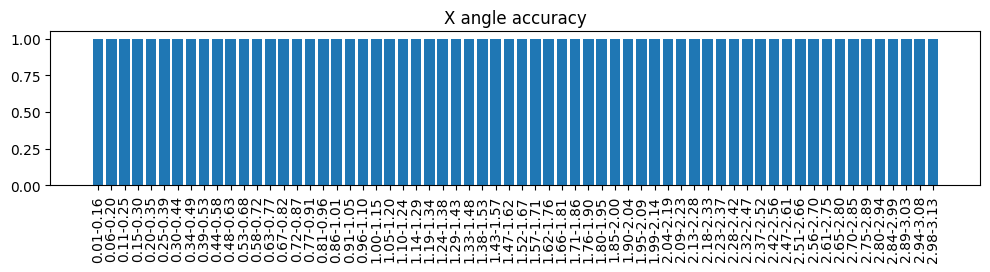

In [54]:
particles_filtered = [p for p in particles_initial if p.event_id == test_params.eventId]
xAngleBins, xAngleAccuracies = get_accuracy_by_x_angle(particles_filtered, particle_to_solutions_map, test_params)
draw_bar_chart(xAngleBins, xAngleAccuracies, "X angle accuracy", figure_size=(12, 2), draw_values=False)

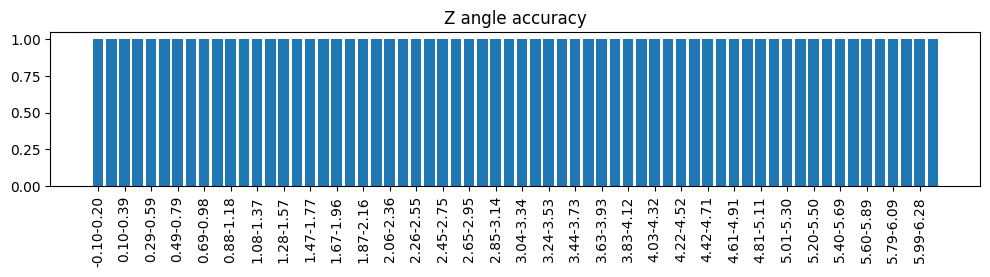

In [55]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

z_angle_bins, z_angle_accuracies = get_accuracy_by_z_angle(particles_filtered, particle_to_solutions_map, test_params)
draw_bar_chart(z_angle_bins, z_angle_accuracies, "Z angle accuracy", figure_size=(12, 2), max_xticks=32, draw_values=False)

# RPPI accuracy by z-angle margin

In [56]:
erase_test_list()

In [57]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_zangle_margin/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_zangle_margin/results.csv"
test_params.xAngleMargin = math.pi / 64
test_params.numZRanges = 32
test_params.numXRanges = 64
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

random.seed(42)
def particle_to_params_func(particle):
    r = 1666
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_zangle_margin/inputSpacepointsGenerationParams.csv")

margins = [math.pi * i / 32 / 16 for i in range(32)]
margins[0] = 1e-6
for i, margin in enumerate(margins):
    test_params.zAngleMargin = margin
    test_params.outputResultsFile = base_dir + f"/quality_tests/rppi_accuracy_by_zangle_margin/results_{i}.csv"
    write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_zangle_margin", base_dir_relative + f"/quality_tests/rppi_accuracy_by_zangle_margin/config_{i}.json")
    add_test_to_list(base_dir + f"/quality_tests/rppi_accuracy_by_zangle_margin/config_{i}.json")

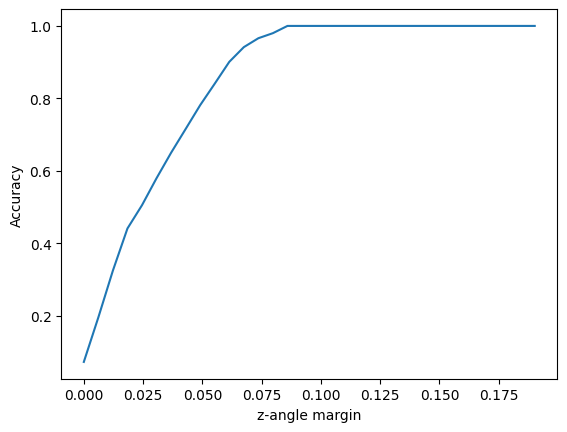

In [58]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

margin_to_accuracy_map = {}
for i, margin in enumerate(margins):
    solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/rppi_accuracy_by_zangle_margin/results_{i}.csv")
    particle_to_solutions_map = map_solutions_to_particles_rppi(particles_filtered, particle_to_generation_params_map, solutions)

    margin_to_accuracy_map[margins[i]] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]

plt.plot(list(margin_to_accuracy_map.keys()), list(margin_to_accuracy_map.values()))
plt.xlabel("z-angle margin")
plt.ylabel("Accuracy")
plt.show()

# RPPI accuracy by x-angle margin

In [59]:
erase_test_list()

In [60]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_xangle_margin/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_xangle_margin/results.csv"
test_params.zAngleMargin = math.pi / 32
test_params.numZRanges = 32
test_params.numXRanges = 64
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_xangle_margin/inputSpacepointsGenerationParams.csv")

margins = [math.pi * i / 32 / 128 for i in range(32)]
margins[0] = 1e-6
for i, margin in enumerate(margins):
    test_params.xAngleMargin = margin
    test_params.outputResultsFile = base_dir + f"/quality_tests/rppi_accuracy_by_xangle_margin/results_{i}.csv"
    write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_xangle_margin", base_dir_relative + f"/quality_tests/rppi_accuracy_by_xangle_margin/config_{i}.json")
    add_test_to_list(base_dir + f"/quality_tests/rppi_accuracy_by_xangle_margin/config_{i}.json")

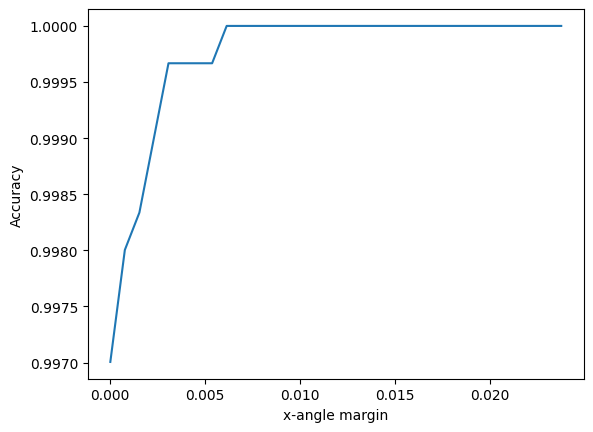

In [61]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

margin_to_accuracy_map = {}
for i, margin in enumerate(margins):
    solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/rppi_accuracy_by_xangle_margin/results_{i}.csv")
    particle_to_solutions_map = map_solutions_to_particles_rppi(particles_filtered, particle_to_generation_params_map, solutions)

    margin_to_accuracy_map[margins[i]] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]

plt.plot(list(margin_to_accuracy_map.keys()), list(margin_to_accuracy_map.values()))
plt.xlabel("x-angle margin")
plt.ylabel("Accuracy")
plt.show()

# RPPI accuracy heatmap for number of x- and z-angle ranges

In [62]:
erase_test_list()

In [63]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_num_ranges/results.csv"

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv")

num_x_rangess = [i for i in range(8, 129, 8)]
num_z_rangess = [i for i in range(8, 129, 8)]

for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        test_params.numXRanges = num_x_ranges
        test_params.numZRanges = num_z_ranges
        test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
        test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
        test_params.outputResultsFile = base_dir + f"/quality_tests/rppi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv"
        write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_num_ranges", base_dir_relative + f"/quality_tests/rppi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")
        add_test_to_list(base_dir + f"/quality_tests/rppi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")

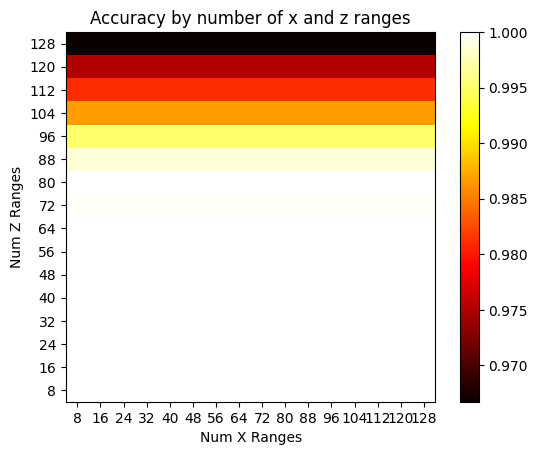

In [64]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

range_pair_to_accuracy_map = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/rppi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv")
        particle_to_solutions_map = map_solutions_to_particles_rppi(particles_filtered, particle_to_generation_params_map, solutions)

        range_pair_to_accuracy_map[(num_x_ranges, num_z_ranges)] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]

draw_heat_map(range_pair_to_accuracy_map, num_x_rangess, num_z_rangess, "Accuracy by number of x and z ranges", "Num X Ranges", "Num Z Ranges")

# Particles initial

# PI - Accuracy for xAngle and zAngle ranges

In [65]:
erase_test_list()

In [66]:
test_params = copy.copy(generic_test_params)
test_params.testType = "ParticlesInitial"
test_params.numZRanges = 64
test_params.numXRanges = 64
test_params.hitsThresholds = [6 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/pi_accuracy_by_region/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/pi_accuracy_by_region/results.csv"

write_config(test_params, base_dir_relative + "/quality_tests/pi_accuracy_by_region", base_dir_relative + "/quality_tests/pi_accuracy_by_region/config.json")
add_test_to_list(base_dir + "/quality_tests/pi_accuracy_by_region/config.json")

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/pi_accuracy_by_region/inputSpacepointsGenerationParams.csv")

In [67]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)
solutions = Solution.read_from_csv(base_dir_relative + "/quality_tests/pi_accuracy_by_region/results.csv")
particle_to_solutions_map = map_solutions_to_particles_pi(particles_filtered, particle_to_generation_params_map, solutions)

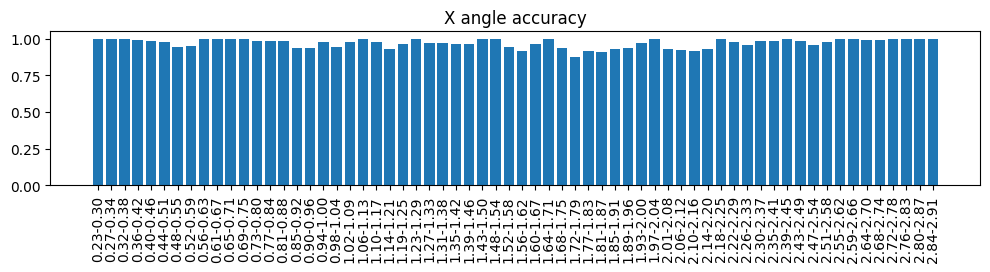

In [68]:
xAngleBins, xAngleAccuracies = get_accuracy_by_x_angle(particles_filtered, particle_to_solutions_map, test_params)
draw_bar_chart(xAngleBins, xAngleAccuracies, "X angle accuracy", figure_size=(12, 2), draw_values=False)

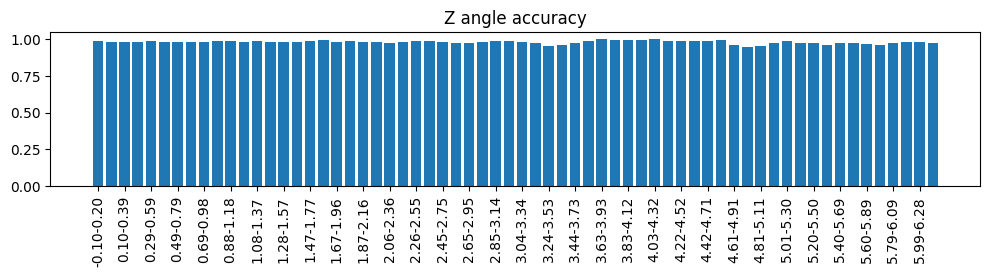

In [69]:
zAngleBins, zAngleAccuracies = get_accuracy_by_z_angle(particles_filtered, particle_to_solutions_map, test_params)
draw_bar_chart(zAngleBins, zAngleAccuracies, "Z angle accuracy", figure_size=(12, 2), max_xticks=32, draw_values=False)

# PI accuracy heatmap for number of x- and z-angle ranges

In [70]:
erase_test_list()

In [71]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/pi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/pi_accuracy_by_num_ranges/results.csv"

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/pi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv")

num_x_rangess = [i for i in range(4, 65, 4)]
num_z_rangess = [i for i in range(4, 65, 4)]

for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        test_params.numXRanges = num_x_ranges
        test_params.numZRanges = num_z_ranges
        test_params.hitsThresholds = [6 for _ in range(test_params.numXRanges)]
        test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
        test_params.outputResultsFile = base_dir + f"/quality_tests/pi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv"
        write_config(test_params, base_dir_relative + "/quality_tests/pi_accuracy_by_num_ranges", base_dir_relative + f"/quality_tests/pi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")
        add_test_to_list(base_dir + f"/quality_tests/pi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")

In [72]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

range_pair_to_accuracy_map = {}
range_pair_to_num_solutions_map = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/pi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv")
        particle_to_solutions_map = map_solutions_to_particles_pi(particles_filtered, particle_to_generation_params_map, solutions)

        range_pair_to_accuracy_map[(num_x_ranges, num_z_ranges)] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]
        range_pair_to_num_solutions_map[(num_x_ranges, num_z_ranges)] = len(solutions)

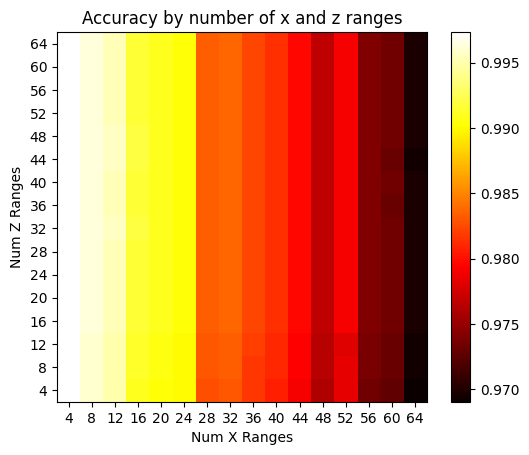

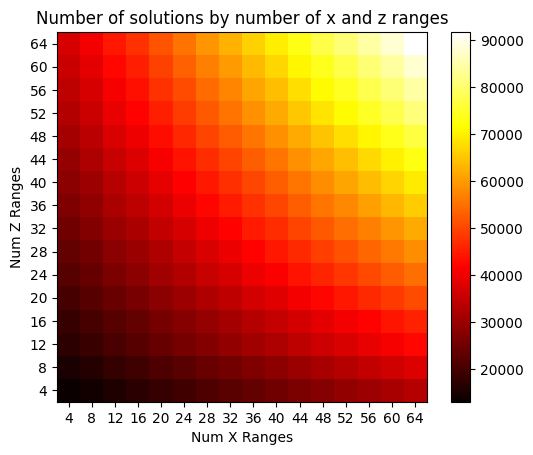

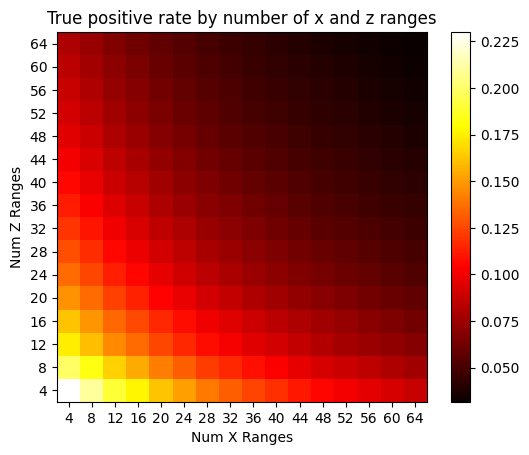

In [73]:
range_pair_to_true_positive_rate_map = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        true_positive_rate = len(particles_filtered) * range_pair_to_accuracy_map[(num_x_ranges, num_z_ranges)] / range_pair_to_num_solutions_map[(num_x_ranges, num_z_ranges)]
        range_pair_to_true_positive_rate_map[(num_x_ranges, num_z_ranges)] = true_positive_rate

draw_heat_map(range_pair_to_accuracy_map, num_x_rangess, num_z_rangess, "Accuracy by number of x and z ranges", "Num X Ranges", "Num Z Ranges")
draw_heat_map(range_pair_to_num_solutions_map, num_x_rangess, num_z_rangess, "Number of solutions by number of x and z ranges", "Num X Ranges", "Num Z Ranges")
draw_heat_map(range_pair_to_true_positive_rate_map, num_x_rangess, num_z_rangess, "True positive rate by number of x and z ranges", "Num X Ranges", "Num Z Ranges")

# Spacepoints full event

# S accuracy by region and hits threshold

In [74]:
erase_test_list()

In [75]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 24
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

for threshold in range(5, 11):
    test_params.hitsThresholds = [threshold for _ in range(test_params.numXRanges)]

    for i in range(20):
        test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_by_region_and_hits_threshold/results_th{threshold}.csv"
        write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_by_region_and_hits_threshold", base_dir_relative + f"/quality_tests/s_accuracy_by_region_and_hits_threshold/config_th{threshold}.json")
        add_test_to_list(base_dir + f"/quality_tests/s_accuracy_by_region_and_hits_threshold/config_th{threshold}.json")

In [76]:
stats_by_threshold = {}
for threshold in range(5, 11):
    solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_accuracy_by_region_and_hits_threshold/results_th{threshold}.csv")
    stats_by_threshold[threshold] = get_stats_for_all_events(particles_initial, solutions_all, test_params)

    for x_angle_range in stats_by_threshold[5]["solutions_count_by_x_angle_range"]:
        if x_angle_range not in stats_by_threshold[threshold]["solutions_count_by_x_angle_range"]:
            stats_by_threshold[threshold]["solutions_count_by_x_angle_range"][x_angle_range] = 0

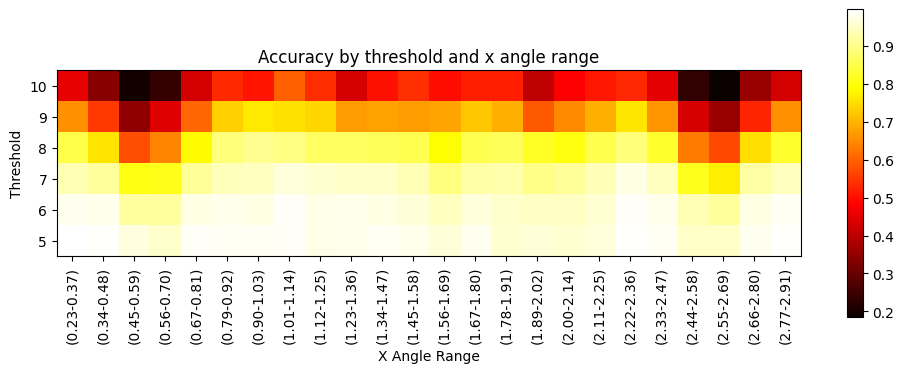

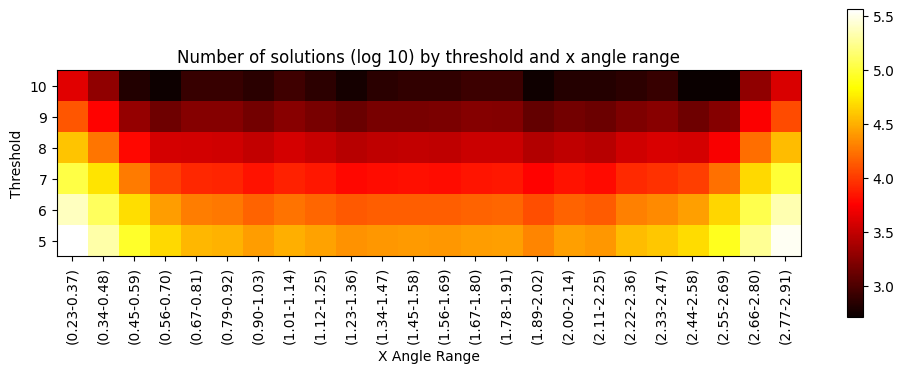

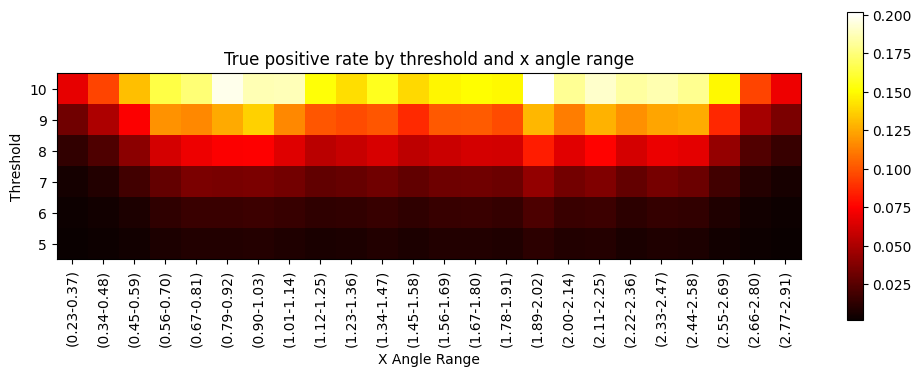

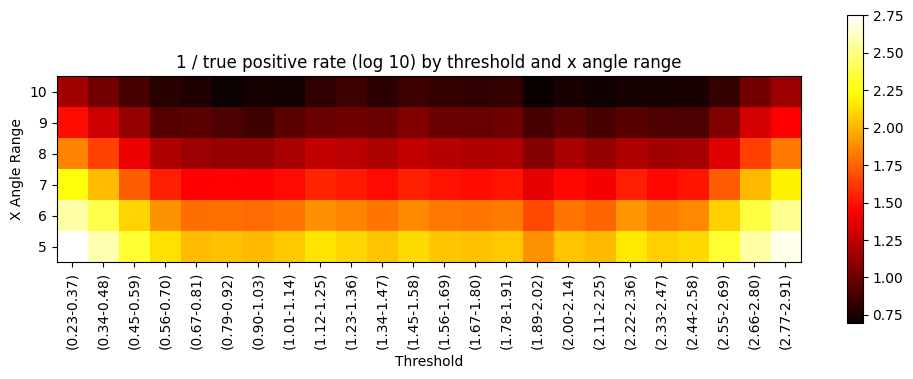

In [77]:
treshold_range_pair_to_accuracy_map = {}
for threshold in range(5, 11):
    for i, accuracy in enumerate(stats_by_threshold[threshold]["x_angle_accuracies_all"]):
        x_angle_range = stats_by_threshold[threshold]["x_angle_bins_all"][i]
        treshold_range_pair_to_accuracy_map[(x_angle_range, threshold)] = accuracy

def x_ticks_label_func(x_value):
    return f"({x_value[0]:.2f}-{x_value[1]:.2f})"
draw_heat_map(treshold_range_pair_to_accuracy_map, stats_by_threshold[5]["x_angle_bins_all"], range(5, 11), "Accuracy by threshold and x angle range", "X Angle Range", "Threshold", figure_size=(12, 4), rotate_x_ticks=True, x_ticks_label_func=x_ticks_label_func)
    
treshold_range_pair_to_num_solutions_map = {}
for threshold in range(5, 11):
    for x_angle_range, num_solutions in stats_by_threshold[threshold]["solutions_count_by_x_angle_range"].items():
        treshold_range_pair_to_num_solutions_map[(x_angle_range, threshold)] = num_solutions

draw_heat_map(treshold_range_pair_to_num_solutions_map, stats_by_threshold[5]["solutions_count_by_x_angle_range"], range(5, 11), "Number of solutions (log 10) by threshold and x angle range", "X Angle Range", "Threshold", figure_size=(12, 4), rotate_x_ticks=True, x_ticks_label_func=x_ticks_label_func, log_scale=True)

treshold_range_pair_to_true_positive_rate_map = {}
for threshold in range(5, 11):
    stats = stats_by_threshold[threshold]
    for x_angle_range, num_solutions, index in zip(stats["solutions_count_by_x_angle_range"].keys(), stats["solutions_count_by_x_angle_range"].values(), range(len(stats["solutions_count_by_x_angle_range"]))):
        count = stats["x_angle_counts_all"][index]
        accuracy = stats["x_angle_accuracies_all"][index]

        if num_solutions == 0:
            treshold_range_pair_to_true_positive_rate_map[(x_angle_range, threshold)] = 0
        else:
            treshold_range_pair_to_true_positive_rate_map[(x_angle_range, threshold)] = min(1, count * accuracy / num_solutions)

draw_heat_map(treshold_range_pair_to_true_positive_rate_map, stats_by_threshold[5]["solutions_count_by_x_angle_range"], range(5, 11), "True positive rate by threshold and x angle range", "X Angle Range", "Threshold", figure_size=(12, 4), rotate_x_ticks=True, x_ticks_label_func=x_ticks_label_func)

treshold_range_pair_to_inversed_true_positive_rate_map = {}
for key, value in treshold_range_pair_to_true_positive_rate_map.items():
    treshold_range_pair_to_inversed_true_positive_rate_map[key] = 1 / value if value > 0 else 0

draw_heat_map(treshold_range_pair_to_inversed_true_positive_rate_map, stats_by_threshold[5]["solutions_count_by_x_angle_range"], range(5, 11), "1 / true positive rate (log 10) by threshold and x angle range", "Threshold", "X Angle Range", figure_size=(12, 4), rotate_x_ticks=True, x_ticks_label_func=x_ticks_label_func, log_scale=True)


# S accuracy by region for selected hits thresholds

In [78]:
erase_test_list()

In [79]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 24
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [6 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 8
test_params.hitsThresholds[1] = 7
test_params.hitsThresholds[-2] = 7
test_params.hitsThresholds[-1] = 8

test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_by_region/results_th6.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_by_region", base_dir_relative + f"/quality_tests/s_accuracy_by_region/config_th6.json")
add_test_to_list(base_dir + f"/quality_tests/s_accuracy_by_region/config_th6.json")

[643, 532, 431, 366, 325, 299, 257, 270, 205, 188, 224, 199, 229, 244, 239, 273, 251, 249, 249, 330, 395, 411, 505, 653]
[558, 498, 396, 337, 316, 293, 250, 267, 200, 184, 218, 192, 216, 236, 228, 259, 238, 239, 246, 323, 369, 369, 447, 541]
0.87 0.94 0.92 0.92 0.97 0.98 0.97 0.99 0.98 0.98 0.97 0.96 0.94 0.97 0.95 0.95 0.95 0.96 0.99 0.98 0.93 0.90 0.89 0.83 


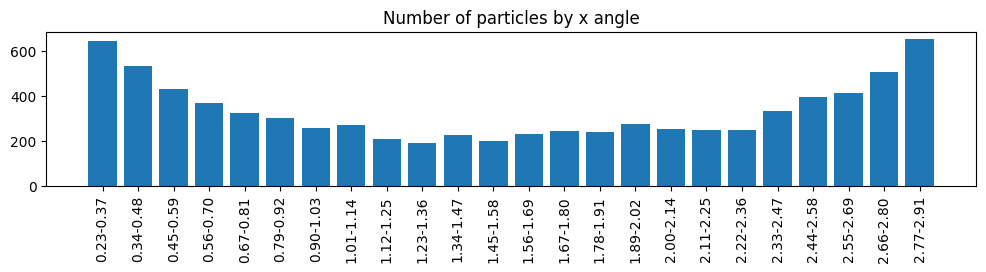

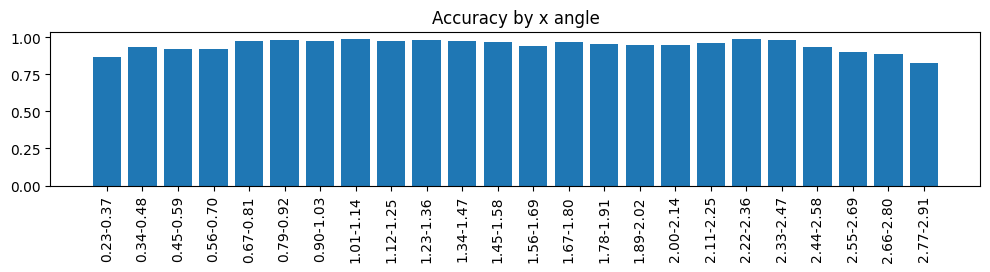

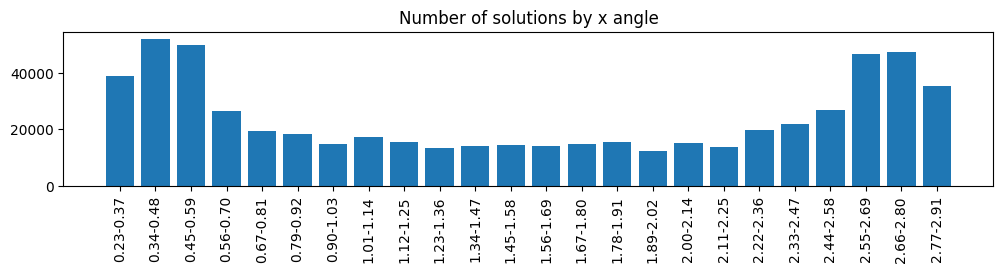

[5222, 949, 264, 119, 34, 20, 16, 9, 9, 4, 1, 5, 2, 2, 3, 1, 3, 3, 4, 1, 2, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]
[4858, 886, 252, 115, 32, 20, 16, 8, 9, 3, 1, 5, 2, 2, 3, 0, 3, 3, 4, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.93 0.93 0.95 0.97 0.94 1.00 1.00 0.89 1.00 0.75 1.00 1.00 1.00 1.00 1.00 0.00 1.00 1.00 1.00 1.00 0.00 1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 


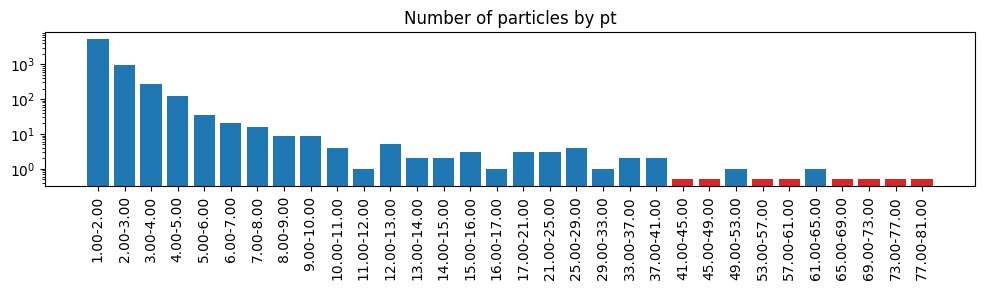

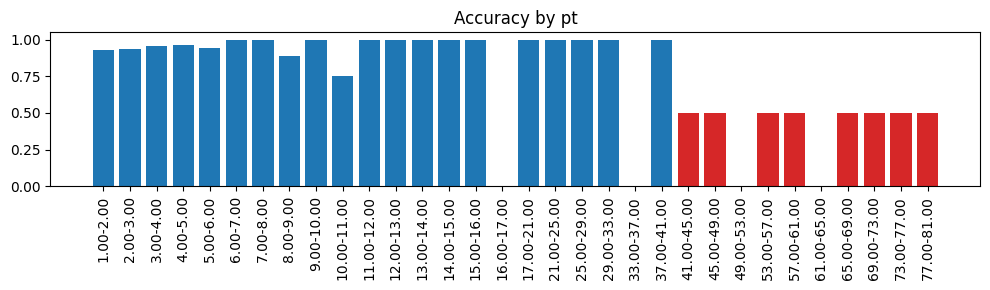

In [80]:
solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_accuracy_by_region/results_th6.csv")
stats = get_stats_for_all_events(particles_initial, solutions_all, test_params)

print(stats["x_angle_counts_all"])
print(stats["x_angle_sums_all"])
for i in range(len(stats["x_angle_accuracies_all"])):
    print(f"{stats['x_angle_accuracies_all'][i]:.2f}", end=" ")
print()

zero_count_mask = [stats["x_angle_counts_all"][i] == 0 for i in range(len(stats["x_angle_bins_all"]))]
draw_bar_chart(stats["x_angle_bins_all"], stats["x_angle_counts_all"], "Number of particles by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
draw_bar_chart(stats["x_angle_bins_all"], stats["x_angle_accuracies_all"], "Accuracy by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
draw_bar_chart(list(stats["solutions_count_by_x_angle_range"].keys()), [stats["solutions_count_by_x_angle_range"][i] for i in stats["solutions_count_by_x_angle_range"].keys()], "Number of solutions by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=False)

print(stats["pt_counts_all"])
print(stats["pt_sums_all"])
for i in range(len(stats["pt_accuracies_all"])):
    print(f"{stats['pt_accuracies_all'][i]:.2f}", end=" ")
print()

zero_count_mask = [stats["pt_counts_all"][i] == 0 for i in range(len(stats["pt_bins_all"]))]
draw_bar_chart(stats["pt_bins_all"], stats["pt_counts_all"], "Number of particles by pt", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=True)
draw_bar_chart(stats["pt_bins_all"], stats["pt_accuracies_all"], "Accuracy by pt", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)

In [81]:
erase_test_list()

In [82]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 24
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 9
test_params.hitsThresholds[1] = 8
test_params.hitsThresholds[-2] = 8
test_params.hitsThresholds[-1] = 9

test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_by_region/results_th7.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_by_region", base_dir_relative + f"/quality_tests/s_accuracy_by_region/config_th7.json")
add_test_to_list(base_dir + f"/quality_tests/s_accuracy_by_region/config_th7.json")

[643, 532, 431, 366, 325, 299, 257, 270, 205, 188, 224, 199, 229, 244, 239, 273, 251, 249, 249, 330, 395, 411, 505, 653]
[369, 349, 244, 229, 259, 261, 230, 246, 180, 167, 198, 173, 186, 205, 208, 222, 199, 214, 226, 284, 252, 234, 307, 356]
0.57 0.66 0.57 0.63 0.80 0.87 0.89 0.91 0.88 0.89 0.88 0.87 0.81 0.84 0.87 0.81 0.79 0.86 0.91 0.86 0.64 0.57 0.61 0.55 


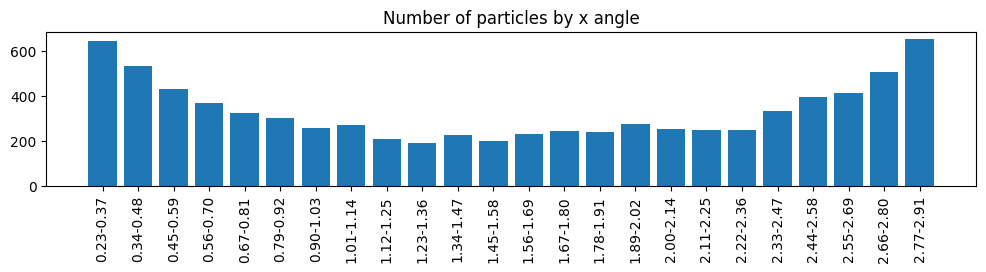

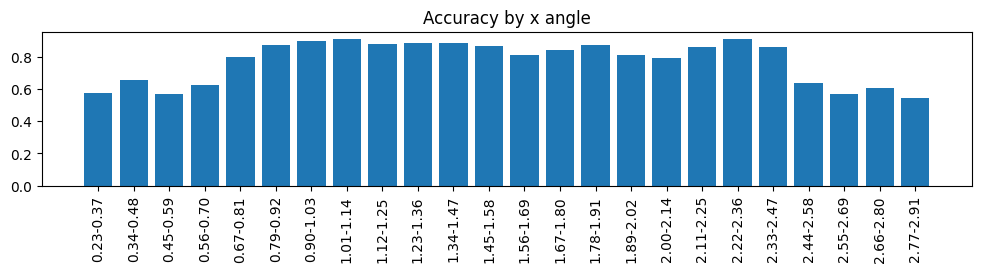

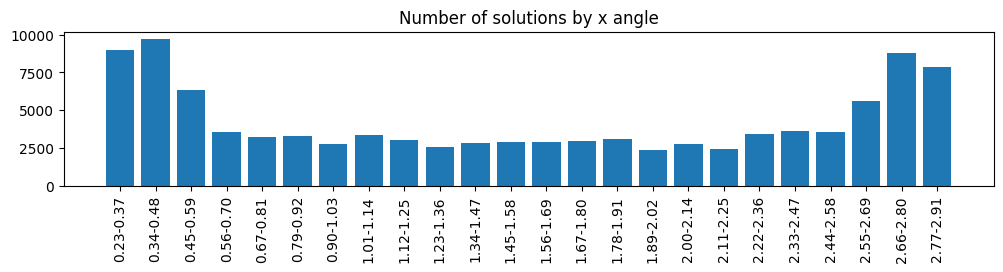

[5222, 949, 264, 119, 34, 20, 16, 9, 9, 4, 1, 5, 2, 2, 3, 1, 3, 3, 4, 1, 2, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]
[3714, 738, 219, 99, 29, 19, 16, 8, 8, 2, 1, 4, 2, 2, 3, 0, 3, 3, 3, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.71 0.78 0.83 0.83 0.85 0.95 1.00 0.89 0.89 0.50 1.00 0.80 1.00 1.00 1.00 0.00 1.00 1.00 0.75 1.00 0.00 1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 


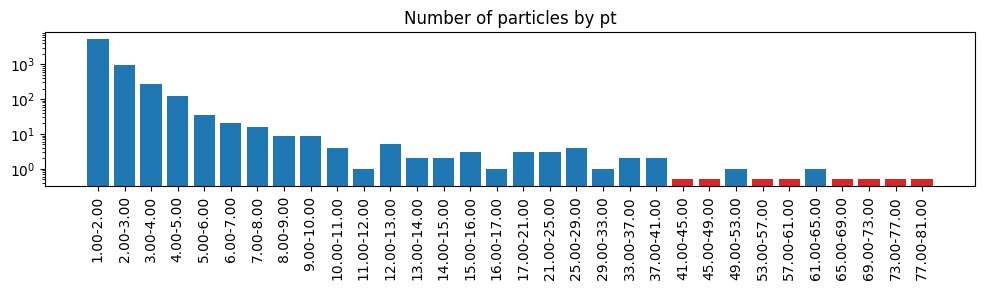

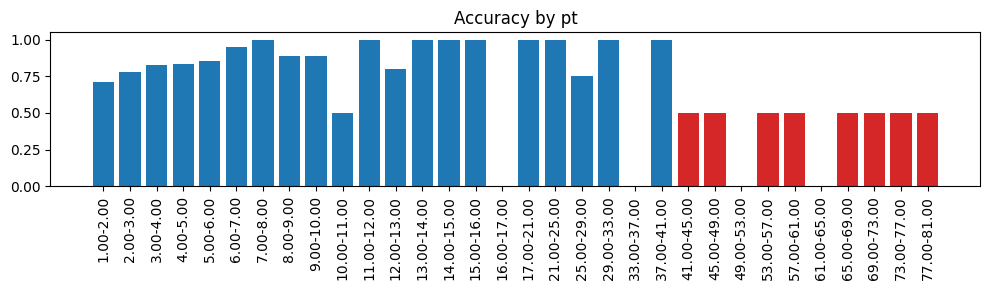

In [83]:
solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_accuracy_by_region/results_th7.csv")
stats = get_stats_for_all_events(particles_initial, solutions_all, test_params)

print(stats["x_angle_counts_all"])
print(stats["x_angle_sums_all"])
for i in range(len(stats["x_angle_accuracies_all"])):
    print(f"{stats['x_angle_accuracies_all'][i]:.2f}", end=" ")
print()

zero_count_mask = [stats["x_angle_counts_all"][i] == 0 for i in range(len(stats["x_angle_bins_all"]))]
draw_bar_chart(stats["x_angle_bins_all"], stats["x_angle_counts_all"], "Number of particles by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
draw_bar_chart(stats["x_angle_bins_all"], stats["x_angle_accuracies_all"], "Accuracy by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
draw_bar_chart(list(stats["solutions_count_by_x_angle_range"].keys()), [stats["solutions_count_by_x_angle_range"][i] for i in stats["solutions_count_by_x_angle_range"].keys()], "Number of solutions by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=False)

print(stats["pt_counts_all"])
print(stats["pt_sums_all"])
for i in range(len(stats["pt_accuracies_all"])):
    print(f"{stats['pt_accuracies_all'][i]:.2f}", end=" ")
print()

zero_count_mask = [stats["pt_counts_all"][i] == 0 for i in range(len(stats["pt_bins_all"]))]
draw_bar_chart(stats["pt_bins_all"], stats["pt_counts_all"], "Number of particles by pt", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=True)
draw_bar_chart(stats["pt_bins_all"], stats["pt_accuracies_all"], "Accuracy by pt", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)

In [84]:
erase_test_list()

In [85]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 24
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [8 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 10
test_params.hitsThresholds[1] = 9
test_params.hitsThresholds[-2] = 9
test_params.hitsThresholds[-1] = 10

test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_by_region/results_th8.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_by_region", base_dir_relative + f"/quality_tests/s_accuracy_by_region/config_th8.json")
add_test_to_list(base_dir + f"/quality_tests/s_accuracy_by_region/config_th8.json")

[643, 532, 431, 366, 325, 299, 257, 270, 205, 188, 224, 199, 229, 244, 239, 273, 251, 249, 249, 330, 395, 411, 505, 653]
[265, 275, 195, 204, 232, 249, 224, 235, 171, 153, 183, 161, 173, 196, 198, 210, 186, 199, 215, 256, 208, 183, 218, 238]
0.41 0.52 0.45 0.56 0.71 0.83 0.87 0.87 0.83 0.81 0.82 0.81 0.76 0.80 0.83 0.77 0.74 0.80 0.86 0.78 0.53 0.45 0.43 0.36 


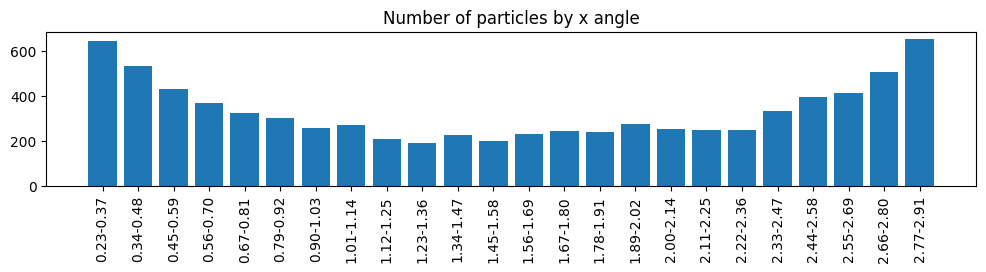

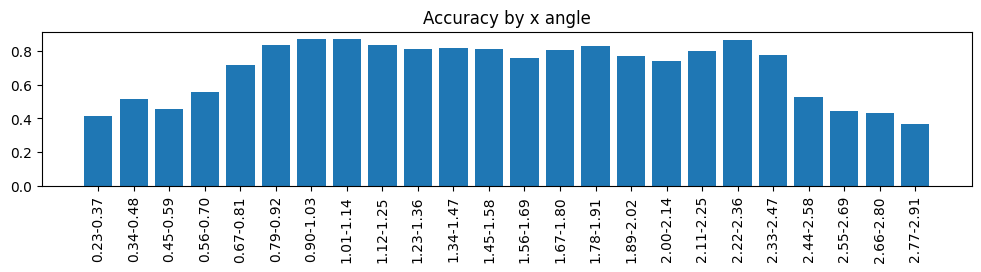

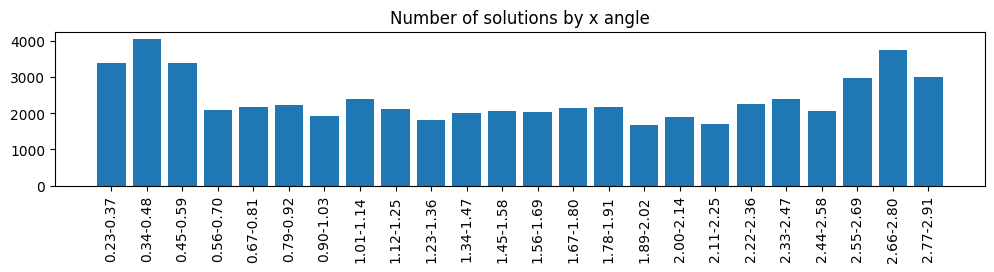

[5222, 949, 264, 119, 34, 20, 16, 9, 9, 4, 1, 5, 2, 2, 3, 1, 3, 3, 4, 1, 2, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]
[3166, 665, 199, 94, 29, 19, 15, 8, 7, 2, 1, 4, 2, 2, 3, 0, 1, 3, 2, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.61 0.70 0.75 0.79 0.85 0.95 0.94 0.89 0.78 0.50 1.00 0.80 1.00 1.00 1.00 0.00 0.33 1.00 0.50 1.00 0.00 1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 


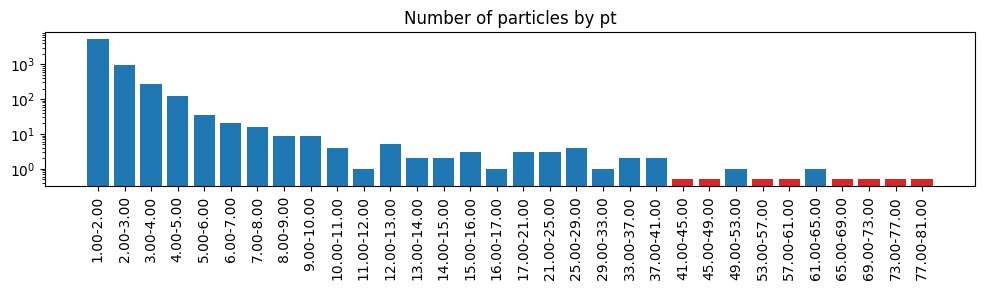

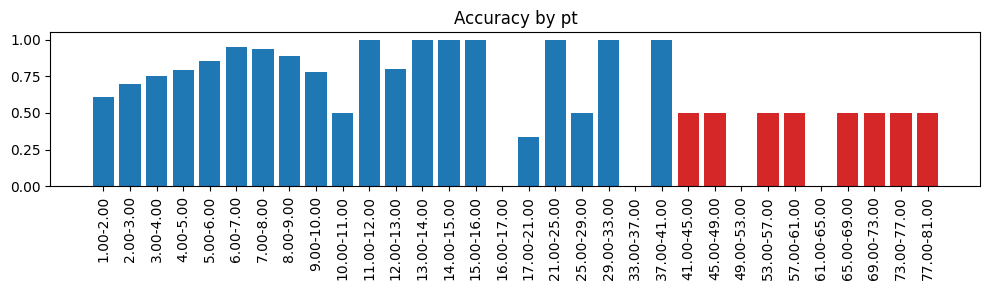

In [86]:
solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_accuracy_by_region/results_th8.csv")
stats = get_stats_for_all_events(particles_initial, solutions_all, test_params)

print(stats["x_angle_counts_all"])
print(stats["x_angle_sums_all"])
for i in range(len(stats["x_angle_accuracies_all"])):
    print(f"{stats['x_angle_accuracies_all'][i]:.2f}", end=" ")
print()

zero_count_mask = [stats["x_angle_counts_all"][i] == 0 for i in range(len(stats["x_angle_bins_all"]))]
draw_bar_chart(stats["x_angle_bins_all"], stats["x_angle_counts_all"], "Number of particles by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
draw_bar_chart(stats["x_angle_bins_all"], stats["x_angle_accuracies_all"], "Accuracy by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
draw_bar_chart(list(stats["solutions_count_by_x_angle_range"].keys()), [stats["solutions_count_by_x_angle_range"][i] for i in stats["solutions_count_by_x_angle_range"].keys()], "Number of solutions by x angle", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=False)

print(stats["pt_counts_all"])
print(stats["pt_sums_all"])
for i in range(len(stats["pt_accuracies_all"])):
    print(f"{stats['pt_accuracies_all'][i]:.2f}", end=" ")
print()

zero_count_mask = [stats["pt_counts_all"][i] == 0 for i in range(len(stats["pt_bins_all"]))]
draw_bar_chart(stats["pt_bins_all"], stats["pt_counts_all"], "Number of particles by pt", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=True)
draw_bar_chart(stats["pt_bins_all"], stats["pt_accuracies_all"], "Accuracy by pt", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)

# S accidentaly correct solutions by region for selected hits thresholds

In [87]:
erase_test_list()

In [88]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 24
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [6 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 8
test_params.hitsThresholds[1] = 7
test_params.hitsThresholds[-2] = 7
test_params.hitsThresholds[-1] = 8

test_params.outputResultsFile = base_dir + f"/quality_tests/s_correct_by_accident/results_th6.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_correct_by_accident", base_dir_relative + f"/quality_tests/s_correct_by_accident/config_th6.json")
add_test_to_list(base_dir + f"/quality_tests/s_correct_by_accident/config_th6.json")


test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 24
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [8 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 10
test_params.hitsThresholds[1] = 9
test_params.hitsThresholds[-2] = 9
test_params.hitsThresholds[-1] = 10

test_params.outputResultsFile = base_dir + f"/quality_tests/s_correct_by_accident/results_th8.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_correct_by_accident", base_dir_relative + f"/quality_tests/s_correct_by_accident/config_th8.json")
add_test_to_list(base_dir + f"/quality_tests/s_correct_by_accident/config_th8.json")

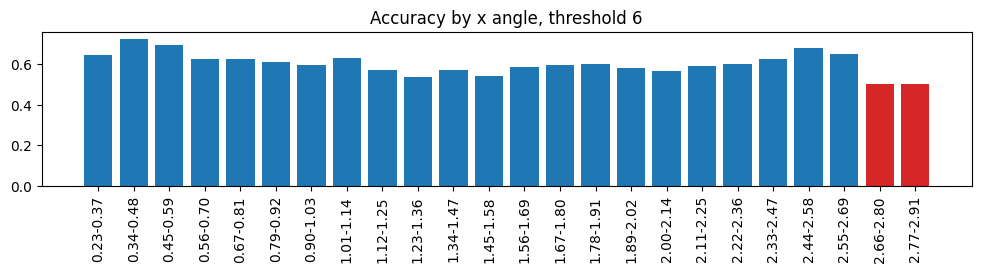

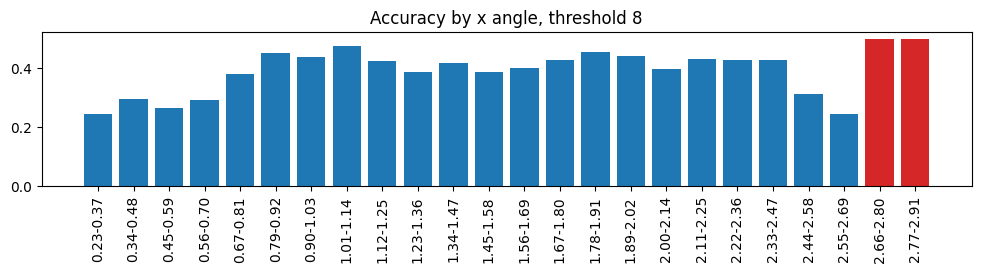

In [89]:
solutions_all_th6 = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_correct_by_accident/results_th6.csv")
stats_th6 = get_stats_for_all_events(particles_initial, solutions_all_th6, test_params, q_negative=False)

solutions_all_th8 = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_correct_by_accident/results_th8.csv")
stats_th8 = get_stats_for_all_events(particles_initial, solutions_all_th8, test_params, q_negative=False)

draw_bar_chart(stats_th6["x_angle_bins_all"], stats_th6["x_angle_accuracies_all"], "Accuracy by x angle, threshold 6", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
draw_bar_chart(stats_th8["x_angle_bins_all"], stats_th8["x_angle_accuracies_all"], "Accuracy by x angle, threshold 8", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)


# S accuracy correlations

In [90]:
erase_test_list()

In [91]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 24
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [6 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 8
test_params.hitsThresholds[1] = 7
test_params.hitsThresholds[-2] = 7
test_params.hitsThresholds[-1] = 8

test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_correlations/results.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_correlations", base_dir_relative + f"/quality_tests/s_accuracy_correlations/config.json")
add_test_to_list(base_dir + f"/quality_tests/s_accuracy_correlations/config.json")

In [92]:
solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_accuracy_correlations/results.csv")

particles_filtered_all = []
found_particles = []
not_found_particles = []

for event_id in range(20):
    particles_filtered = [p for p in particles_initial if math.sqrt(p.vx ** 2 + p.vy ** 2) < 10 and abs(p.vz) < 200]
    particles_filtered = filter_particles_by_x_angle_event_id_pt_and_q(particles_filtered, event_id, test_params.minXAngle, test_params.maxXAngle, min_pt=1, q_negative=True)
    solutions = [s for s in solutions_all if s.event_id == event_id]

    particles_filtered_all.extend(particles_filtered)
    particle_to_solutions_map = map_solutions_to_particles_s(particles_filtered, solutions)
    for particle in particles_filtered:
        if particle.particle_id in particle_to_solutions_map:
            found_particles.append(particle)
        else:
            not_found_particles.append(particle)

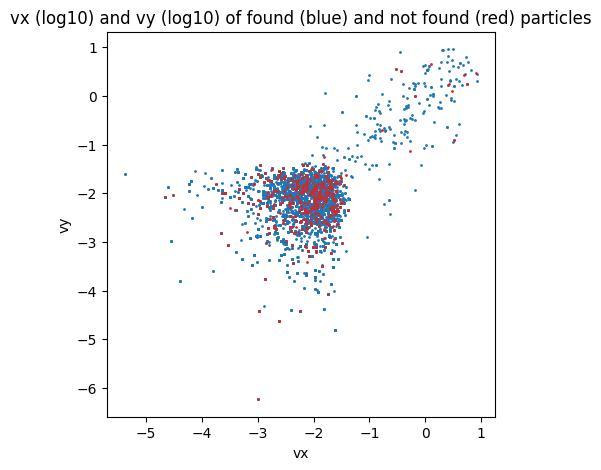

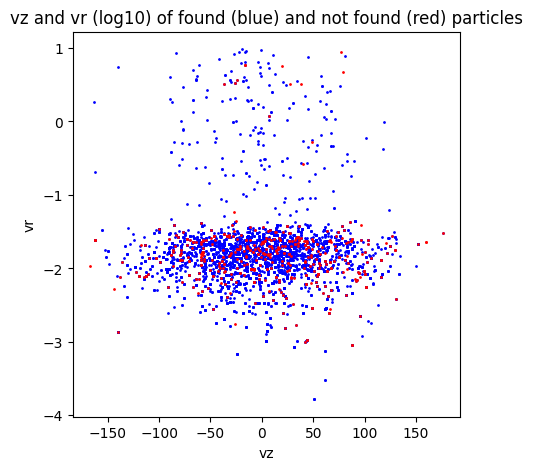

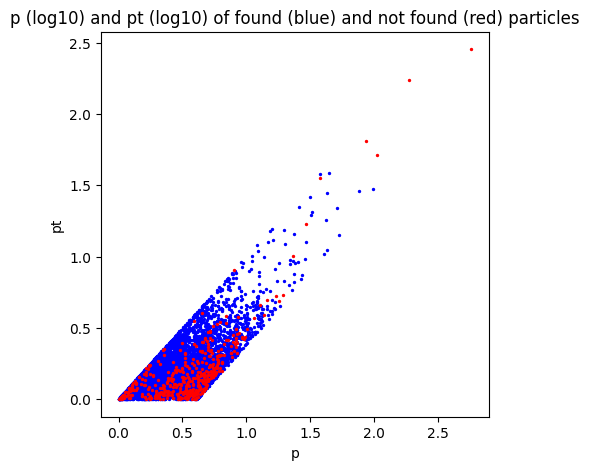

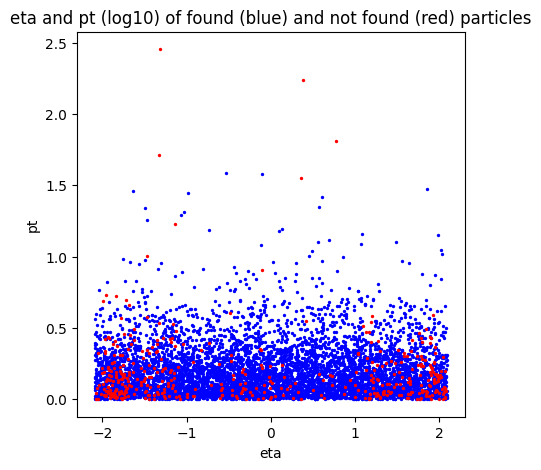

In [93]:
found_vx = [math.log10(abs(p.vx)) for p in found_particles]
found_vy = [math.log10(abs(p.vy)) for p in found_particles]
not_found_vx = [math.log10(abs(p.vx)) for p in not_found_particles]
not_found_vy = [math.log10(abs(p.vy)) for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_vx, found_vy, color="tab:blue", s=1)
plt.scatter(not_found_vx, not_found_vy, color="tab:red", s=1)
plt.xlabel("vx")
plt.ylabel("vy")
plt.title("vx (log10) and vy (log10) of found (blue) and not found (red) particles")
plt.show()


found_vz = [p.vz for p in found_particles]
found_vr = [math.log10(math.sqrt(p.vx ** 2 + p.vy ** 2)) for p in found_particles]
not_found_vz = [p.vz for p in not_found_particles]
not_found_vr = [math.log10(math.sqrt(p.vx ** 2 + p.vy ** 2)) for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_vz, found_vr, color="blue", s=1)
plt.scatter(not_found_vz, not_found_vr, color="red", s=1)
plt.xlabel("vz")
plt.ylabel("vr")
plt.title("vz and vr (log10) of found (blue) and not found (red) particles")
plt.show()


found_p = [math.log10(p.p) for p in found_particles]
found_pt = [math.log10(p.pt) for p in found_particles]
not_found_p = [math.log10(p.p) for p in not_found_particles]
not_found_pt = [math.log10(p.pt) for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_p, found_pt, color="blue", s=2)
plt.scatter(not_found_p, not_found_pt, color="red", s=2)
plt.xlabel("p")
plt.ylabel("pt")
plt.title("p (log10) and pt (log10) of found (blue) and not found (red) particles")
plt.show()


found_eta = [p.eta for p in found_particles]
not_found_eta = [p.eta for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_eta, found_pt, color="blue", s=2)
plt.scatter(not_found_eta, not_found_pt, color="red", s=2)
plt.xlabel("eta")
plt.ylabel("pt")
plt.title("eta and pt (log10) of found (blue) and not found (red) particles")
plt.show()